Optimal K: 3


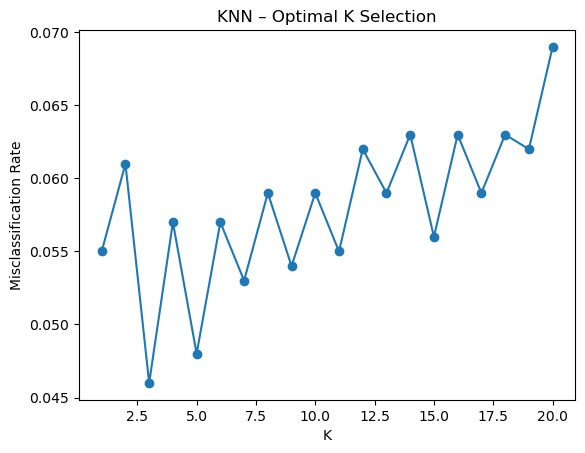

KNN (K = 3 )
Accuracy: 0.954
Recall: 0.5729
Precision: 0.9167
F1 Score: 0.7051
AUC: 0.8867
Misclassification Rate: 0.046
K-Fold CV (k=10)
Mean CV Accuracy: 0.9542
Std CV Accuracy: 0.0093

Confusion Matrix:
                  Predicted: Denied  Predicted: Approved
Actual: Denied                  899                    5
Actual: Approved                 41                   55

Overfitting Check:
Train Accuracy: 0.9738
Test Accuracy: 0.954
Train AUC: 0.9959
Test AUC: 0.8867


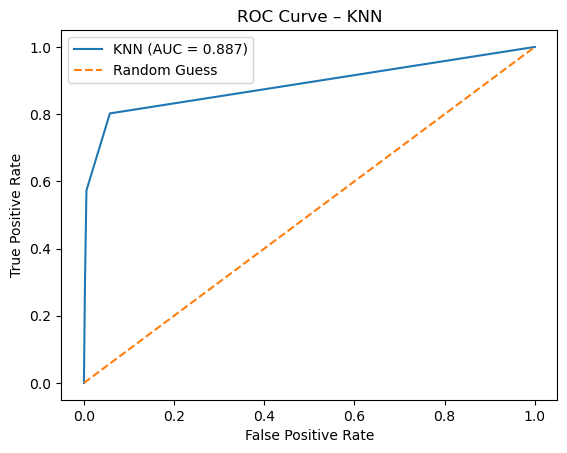

In [15]:
# KNN Classifier – Loan Approval Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score,
    roc_auc_score, roc_curve, confusion_matrix
)

# =========================
# 1. Load Data
# =========================
df = pd.read_excel("455 Data.xlsx")
df.columns = df.columns.str.strip()

# =========================
# 2. Variables
# =========================
target = "Personal.Loan"

predictors = [
    "Age",
    "Experience",
    "Family",
    "CCAvg",
    "Education",
    "Mortgage",
    "Securities.Account",
    "CD.Account",
    "Online",
    "CreditCard",
    "Median Income Per City",
    "Income / Median in city"
]

data = df[[target] + predictors].dropna()

X = data[predictors]
y = data[target]

# =========================
# 3. Train/Test Split
# 80/20 split with stratify — preserves 90/10 class imbalance
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =========================
# 4. Find Optimal K
# test K from 1 to 20 and select K with lowest misclassification rate
# data is already standardized — no additional scaling required
# =========================
k_range = range(1, 21)
error_rates = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    error_rates.append(1 - knn.score(X_test, y_test))

best_k = k_range[np.argmin(error_rates)]
print("Optimal K:", best_k)

plt.figure()
plt.plot(k_range, error_rates, marker='o')
plt.xlabel("K")
plt.ylabel("Misclassification Rate")
plt.title("KNN – Optimal K Selection")
plt.show()

# =========================
# 5. Fit Final KNN Model (optimal K)
# =========================
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

# =========================
# 6. Predictions
# =========================
y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:, 1]

# =========================
# 7. Metrics
# =========================
accuracy  = accuracy_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_prob)

print("KNN (K =", best_k, ")")
print("Accuracy:",  round(accuracy, 4))
print("Recall:",    round(recall, 4))
print("Precision:", round(precision, 4))
print("F1 Score:",  round(f1, 4))
print("AUC:",       round(auc, 4))
print("Misclassification Rate:", round(1 - accuracy, 4))

# =========================
# K-Fold Cross Validation
# 10-fold CV
# =========================
from sklearn.model_selection import KFold, cross_validate

kfold = KFold(10, shuffle=True, random_state=42)

cv_results = cross_validate(knn, X, y,
                            cv=kfold,
                            scoring='accuracy')

print("K-Fold CV (k=10)")
print("Mean CV Accuracy:", round(cv_results['test_score'].mean(), 4))
print("Std CV Accuracy:",  round(cv_results['test_score'].std(), 4))


# =========================
# 8. Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(pd.DataFrame(cm,
                   index=["Actual: Denied", "Actual: Approved"],
                   columns=["Predicted: Denied", "Predicted: Approved"]))

# =========================
# 9. Overfitting Check
# =========================
print("\nOverfitting Check:")
print("Train Accuracy:", round(accuracy_score(y_train, knn.predict(X_train)), 4))
print("Test Accuracy:",  round(accuracy, 4))
print("Train AUC:", round(roc_auc_score(y_train, knn.predict_proba(X_train)[:,1]), 4))
print("Test AUC:",  round(auc, 4))

# =========================
# 10. ROC Curve
# =========================
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"KNN (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – KNN")
plt.legend()
plt.show()

In [16]:
# test refit with larger K to reduce overfitting
#7
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:, 1]

print("Train AUC:", round(roc_auc_score(y_train, knn.predict_proba(X_train)[:,1]), 4))
print("Test AUC:",  round(roc_auc_score(y_test, y_prob), 4))
print("Recall:",    round(recall_score(y_test, y_pred), 4))

Train AUC: 0.9923
Test AUC: 0.942
Recall: 0.4688


In [17]:
#5
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train, y_train)
y_pred5 = knn5.predict(X_test)
y_prob5 = knn5.predict_proba(X_test)[:,1]
print("K=5 Recall:", round(recall_score(y_test, y_pred5), 4))
print("K=5 AUC:", round(roc_auc_score(y_test, y_prob5), 4))

K=5 Recall: 0.5312
K=5 AUC: 0.9205


In [18]:
# =========================
# 11. Conclusion
# =========================
# K values tested:
#   K=3 — Recall: 0.5729, AUC: 0.8867 (selected)
#   K=5 — Recall: 0.5312, AUC: 0.9205
#   K=7 — Recall: 0.4688, AUC: 0.9420
#
# - As K increases, AUC improves but recall drops consistently
# - 90/10 class imbalance causes majority class to dominate at larger K
# - K=3 selected — recall is the priority in a loan approval context
# - Train/test AUC gap (0.9959 vs 0.8867) indicates mild overfitting

In [19]:
from sklearn.model_selection import KFold, cross_validate

for k in [3, 5, 7]:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    y_pred_k = knn_k.predict(X_test)
    y_prob_k = knn_k.predict_proba(X_test)[:,1]
    kfold = KFold(10, shuffle=True, random_state=42)
    cv_k = cross_validate(knn_k, X, y, cv=kfold, scoring='accuracy')
    print(f"K={k}")
    print("Accuracy:",  round(accuracy_score(y_test, y_pred_k), 4))
    print("Recall:",    round(recall_score(y_test, y_pred_k), 4))
    print("Precision:", round(precision_score(y_test, y_pred_k), 4))
    print("F1:",        round(f1_score(y_test, y_pred_k), 4))
    print("Train AUC:", round(roc_auc_score(y_train, knn_k.predict_proba(X_train)[:,1]), 4))
    print("Test AUC:",  round(roc_auc_score(y_test, y_prob_k), 4))
    print("CV Mean:",   round(cv_k['test_score'].mean(), 4))
    print("CV Std:",    round(cv_k['test_score'].std(), 4))
    print()

K=3
Accuracy: 0.954
Recall: 0.5729
Precision: 0.9167
F1: 0.7051
Train AUC: 0.9959
Test AUC: 0.8867
CV Mean: 0.9542
CV Std: 0.0093

K=5
Accuracy: 0.952
Recall: 0.5312
Precision: 0.9444
F1: 0.68
Train AUC: 0.994
Test AUC: 0.9205
CV Mean: 0.9514
CV Std: 0.009

K=7
Accuracy: 0.947
Recall: 0.4688
Precision: 0.9574
F1: 0.6294
Train AUC: 0.9923
Test AUC: 0.942
CV Mean: 0.9478
CV Std: 0.0102

